# Analyse Tweets US Airline - Reponses aux 6 questions

Ce notebook repond point par point a l enonce:
1. Charger le dataset
2. Obtenir les informations de base avec pandas
3. Identifier les variables utiles pour la classification
4. Encoder airline_sentiment en 0, 1, 2
5. Separarer train/validation et test
6. Creer un pipeline avec suppression des variables inutiles et pretraitement maison

## Question 1 - Charger le dataset

On charge le fichier CSV contenant les tweets.

## Question 2 - Informations de base avec pandas

On affiche le nombre d observations et variables, les types de colonnes, les valeurs manquantes et la distribution de la cible.

In [19]:
import pandas as pd

DATA_PATH = 'Tweets (2).csv'
TARGET = 'airline_sentiment'

df = pd.read_csv(DATA_PATH)

print('Dataset charge avec succes')
print('Shape:', df.shape)
df.head()

Dataset charge avec succes
Shape: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## Question 3 - Variables utiles pour classifier airline_sentiment

On propose une liste de variables explicatives pertinentes, en privilegiant le contenu textuel et quelques metadonnees.

In [20]:
print('Shape:', df.shape)
print('\nTypes:')
print(df.dtypes)
print('\nValeurs manquantes:')
print(df.isna().sum())
print('\nDistribution de la cible:')
print(df[TARGET].value_counts())

Shape: (14640, 15)

Types:
tweet_id                          int64
airline_sentiment                   str
airline_sentiment_confidence    float64
negativereason                      str
negativereason_confidence       float64
airline                             str
airline_sentiment_gold              str
name                                str
negativereason_gold                 str
retweet_count                     int64
text                                str
tweet_coord                         str
tweet_created                       str
tweet_location                      str
user_timezone                       str
dtype: object

Valeurs manquantes:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14

In [21]:
useful_variables = [
    'text',
    'airline',
    'airline_sentiment_confidence',
    'retweet_count',
    'user_timezone',
    'tweet_location',
    'tweet_created',
]

useful_variables = [c for c in useful_variables if c in df.columns]
print('Variables utiles possibles pour la classification de airline_sentiment:')
print(useful_variables)

Variables utiles possibles pour la classification de airline_sentiment:
['text', 'airline', 'airline_sentiment_confidence', 'retweet_count', 'user_timezone', 'tweet_location', 'tweet_created']


## Question 4 - Encoder airline_sentiment en 0, 1, 2

Mapping utilise:
- negative -> 0
- neutral -> 1
- positive -> 2

In [22]:
SENTIMENT_TO_INT = {'negative': 0, 'neutral': 1, 'positive': 2}

df_model = df.copy()
df_model[TARGET] = df_model[TARGET].map(SENTIMENT_TO_INT)
assert not df_model[TARGET].isna().any(), 'Certaines valeurs de la cible ne sont pas mappees.'
df_model[TARGET] = df_model[TARGET].astype(int)

print('Valeurs uniques encodees:', sorted(df_model[TARGET].unique().tolist()))
print(df_model[[TARGET]].head())

Valeurs uniques encodees: [0, 1, 2]
   airline_sentiment
0                  1
1                  2
2                  1
3                  0
4                  0


## Question 5 - Separation train/validation et test

On fait un split stratifie pour conserver la proportion des classes.

In [23]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=42, stratify=y_train_val
)

print('Train+Val:', X_train_val.shape, ' Test:', X_test.shape)
print('Train:', X_train.shape, ' Val:', X_val.shape, ' Test:', X_test.shape)

Train+Val: (11712, 14)  Test: (2928, 14)
Train: (9369, 14)  Val: (2343, 14)  Test: (2928, 14)


## Question 6 - Pipeline de pretraitement

Le pipeline comporte 2 etapes:
1. Suppression des variables inutiles
2. Fonction maison de pretraitement du texte des tweets

In [24]:
import re
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

def drop_useless_variables(dataframe: pd.DataFrame) -> pd.DataFrame:
    return dataframe[['text']].copy()

def clean_tweet_text(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#', ' ', text)
    text = re.sub(r'&amp;', 'and', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_tweets(dataframe: pd.DataFrame) -> pd.DataFrame:
    out = dataframe.copy()
    out['text'] = out['text'].apply(clean_tweet_text)
    return out

pipeline = Pipeline(
    steps=[
        ('drop_useless', FunctionTransformer(drop_useless_variables, validate=False)),
        ('tweet_preprocess', FunctionTransformer(preprocess_tweets, validate=False)),
    ]
)

X_train_ready = pipeline.fit_transform(X_train)
X_val_ready = pipeline.transform(X_val)
X_test_ready = pipeline.transform(X_test)

print('Pipeline applique avec succes')
print(X_train_ready.head())

Pipeline applique avec succes
                                                   text
5119  you rerouted my bf s flight and he s diabetic ...
5193  okay i understand a delay one way but both way...
5152  flight why do multiple tracking sites have mor...
7905        now we are delayed until this is ridiculous
1482      i did it took about an hour and a half though


## 5) Visualiser les resultats et exporter le notebook

On affiche une visualisation simple de la distribution de `airline_sentiment` encodee.
Ensuite, dans VS Code:
- sauvegarder le notebook
- exporter via la commande `Jupyter: Export to Python Script` ou `Export to HTML`.

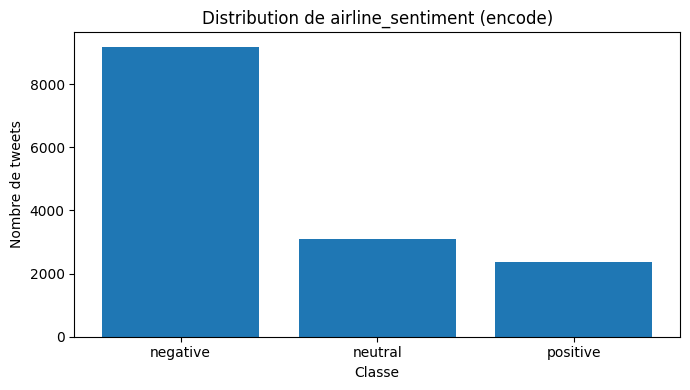

In [25]:
import matplotlib.pyplot as plt

count_by_class = y.value_counts().sort_index()
label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
labels = [label_map[i] for i in count_by_class.index]

plt.figure(figsize=(7, 4))
plt.bar(labels, count_by_class.values)
plt.title('Distribution de airline_sentiment (encode)')
plt.xlabel('Classe')
plt.ylabel('Nombre de tweets')
plt.tight_layout()
plt.show()

### Visualisations EDA complementaires

Cette section ajoute:
- des histogrammes sur des variables numeriques
- une matrice de correlation
- une repartition du sentiment par compagnie aerienne

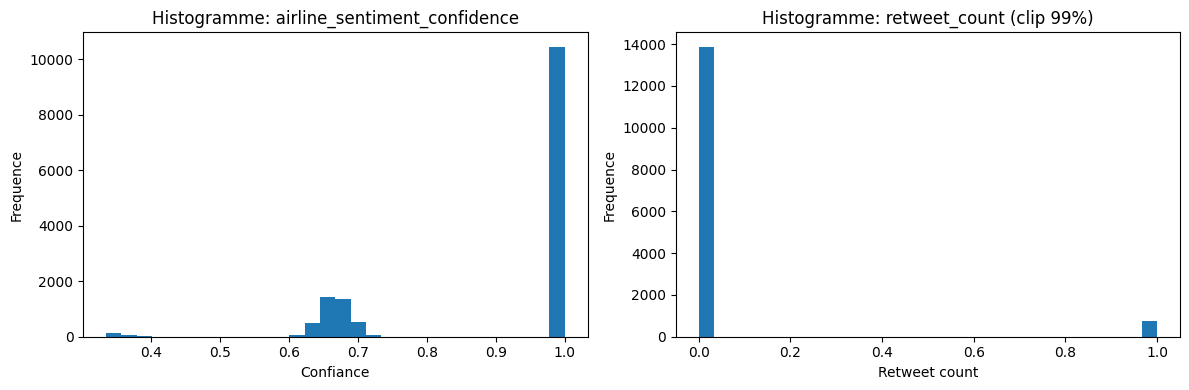

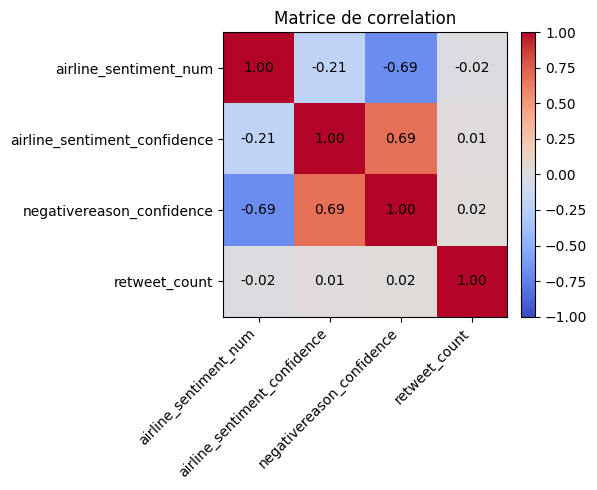

,airline_sentiment_num,airline_sentiment_confidence,negativereason_confidence,retweet_count
airline_sentiment_num,1.000000,-0.205936,-0.693294,-0.015717
airline_sentiment_confidence,-0.205936,1.000000,0.685879,0.012581
negativereason_confidence,-0.693294,0.685879,1.000000,0.021574
retweet_count,-0.015717,0.012581,0.021574,1.000000


In [26]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramme confiance du sentiment
axes[0].hist(df['airline_sentiment_confidence'].dropna(), bins=30)
axes[0].set_title('Histogramme: airline_sentiment_confidence')
axes[0].set_xlabel('Confiance')
axes[0].set_ylabel('Frequence')

# Histogramme retweet_count (tronque au 99e percentile pour lisibilite)
retweet_clip = df['retweet_count'].clip(upper=df['retweet_count'].quantile(0.99))
axes[1].hist(retweet_clip.dropna(), bins=30)
axes[1].set_title('Histogramme: retweet_count (clip 99%)')
axes[1].set_xlabel('Retweet count')
axes[1].set_ylabel('Frequence')

plt.tight_layout()
plt.show()

# Preparation robuste pour correlations
corr_df = df.copy()
corr_df['airline_sentiment_num'] = corr_df['airline_sentiment'].map({'negative': 0, 'neutral': 1, 'positive': 2})

num_cols = [
    'airline_sentiment_num',
    'airline_sentiment_confidence',
    'negativereason_confidence',
    'retweet_count',
]

# On s'assure que toutes les colonnes sont bien numeriques
corr_data = corr_df[num_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(num_cols)))
ax.set_yticks(np.arange(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha='right')
ax.set_yticklabels(num_cols)
ax.set_title('Matrice de correlation')

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr_matrix

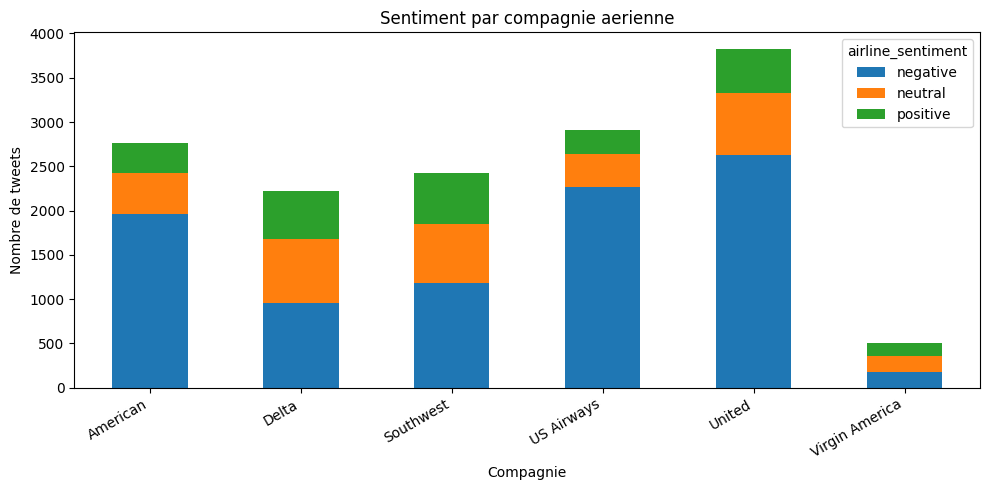

In [27]:
# Repartition du sentiment par compagnie aerienne
sentiment_order = ['negative', 'neutral', 'positive']
ct = pd.crosstab(df['airline'], df['airline_sentiment'])
ct = ct.reindex(columns=[c for c in sentiment_order if c in ct.columns])

ax = ct.plot(kind='bar', stacked=True, figsize=(10, 5))
ax.set_title('Sentiment par compagnie aerienne')
ax.set_xlabel('Compagnie')
ax.set_ylabel('Nombre de tweets')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()